In [1]:
import pandas as pd 
import numpy as np
from collections import defaultdict
import sys
sys.path.append('/Users/fido_josephine/Documents/New-Fraud-Rules/fraud')
from modules.distance_finder import lev_win_multi_weighted
from modules.group_dr import add_multi_chart
ug_df = pd.read_csv('IOS Fraud UG  (1).csv')
ug_df['SURVEY_DATE'] = pd.to_datetime(ug_df['TIME'])
ug_df['HASH'] = ug_df['HASH4']
ug_df['DISBURSED'] = ug_df['DISIBURSED']
ug_df = ug_df.drop('TIME', axis=1)
gh_df = pd.read_csv('/Users/fido_josephine/Documents/New-Fraud-Rules/Data/surveys (1).csv')
gh_df['SURVEY_DATE'] = pd.to_datetime(gh_df['SURVEY_DATE'])

In [2]:
records = []
for i in range(4, 10, 2):
    # for j in range(1, 3, 1):
    output = defaultdict(list) 
    res = lev_win_multi_weighted(gh_df, 15, 4, 6, 2, i, add_weight=1, pos_weight=3)
    # output['dup_limit'] = j
    output['combined_weight'] = i
    output['add_weight'] = 1
    output['pos_weight'] = 3
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)

output1 = pd.DataFrame(records)

In [3]:
output1

,combined_weight,add_weight,pos_weight,n_surveys,n_disbursed,dr
0,4,1,3,553,230,0.326087
1,6,1,3,1312,502,0.280876
2,8,1,3,1900,741,0.263158


In [23]:
records = []
for i in range(4, 10, 2):
    for j in range(2, 7, 1):
        add_weight = 3
        pos_weight = 1
        output = defaultdict(list) 
        res = lev_win_multi_weighted(gh_df, 30, 2, 3, j, i, add_weight=add_weight, pos_weight=pos_weight)
        res['dup_limit'] = j
        res['add_sim'] = 3
        res['pos_sim'] = 3
        #
        output['combined_weight'] = i
        output['add_weight'] = add_weight
        output['pos_weight'] = pos_weight
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)

output1 = pd.DataFrame(records)

In [24]:
output1

,combined_weight,add_weight,pos_weight,n_surveys,n_disbursed,dr
0,4,3,1,430,192,0.390625
1,4,3,1,244,114,0.412281
2,4,3,1,156,78,0.448718
3,4,3,1,106,50,0.460000
4,4,3,1,71,35,0.457143
5,6,3,1,696,335,0.394030
6,6,3,1,403,197,0.380711
7,6,3,1,254,128,0.406250
8,6,3,1,169,80,0.425000
9,6,3,1,115,54,0.425926


In [8]:
res.to_csv('gh_add3_pos3_combined_weight.csv')

In [11]:
records = []
for i in range(1, 5):
    output = defaultdict(list) 
    res = lev_win_multi_weighted(gh_df, 15, 4, 6, 2, i, add_weight=1, pos_weight=2)
    # output['dup_limit'] = j
    output['combined_weight'] = i
    output['add_weight'] = 1
    output['pos_weight'] = 2
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)

output2 = pd.DataFrame(records)
output2


,combined_weight,add_weight,pos_weight,n_surveys,n_disbursed,dr
0,1,1,2,49,25,0.520000
1,2,1,2,83,47,0.680851
2,3,1,2,100,50,0.660000
3,4,1,2,115,58,0.689655


In [11]:
records = []
for i in range(6, 18, 2):
    for j in range(2, 7):
        output = defaultdict(list) 
        res1 = lev_win_multi_weighted(gh_df, 15, 4, 6, j, i, add_weight=1.5, pos_weight=0.5)
        # output['dup_limit'] = j
        output['combined_weight'] = i
        output['dup_limit'] = j
        output['n_surveys'] = res1['CLIENT_ID'].count()
        output['n_disbursed'] = res1['DISBURSED'].sum()
        output['dr'] = res1['DR1'].sum()/res1['DISBURSED'].sum()
        records.append(output)
output3 = pd.DataFrame(records)
output3.head()

,combined_weight,dup_limit,n_surveys,n_disbursed,dr
0,6,2,956,495,0.359596
1,6,3,459,246,0.382114
2,6,4,267,136,0.441176
3,6,5,149,76,0.421053
4,6,6,85,43,0.395349


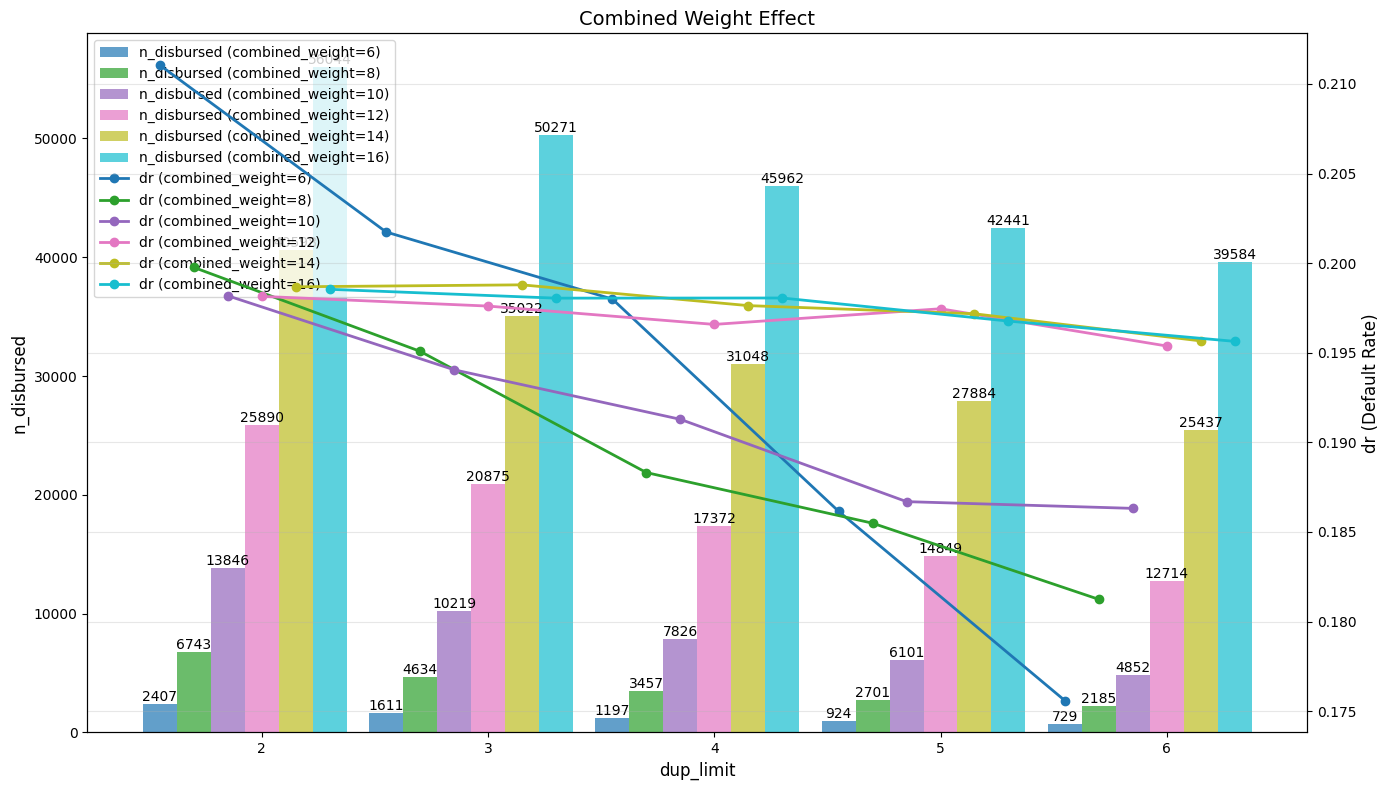

In [10]:
add_multi_chart(output3, 'Combined Weight Effect', 'dup_limit', 'combined_weight')

In [ ]:
# weighted algo fro Uganda case
records = []
for i in range(4, 20, 4):
    for j in range(1, 3, 1):
        output = defaultdict(list) 
        res = lev_win_multi_weighted(ug_df, 15, 4, 6, 2, i, add_weight=0.5, pos_weight=1*1)
        # output['dup_limit'] = j
        output['combined_weight'] = i
        output['add_weight'] = 1*j
        output['pos_weight'] = 2*j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)

output1 = pd.DataFrame(records)

/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_21355/3008697539.py:13: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_21355/3008697539.py:13: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_21355/3008697539.py:13: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()


In [5]:
output1

,combined_weight,add_weight,pos_weight,n_surveys,n_disbursed,dr
0,4,1,2,0,0,NaN
1,4,2,4,0,0,NaN
2,8,1,2,50,50,0.960000
3,8,2,4,0,0,NaN
4,12,1,2,111,111,0.900901
5,12,2,4,16,16,0.937500
6,16,1,2,177,177,0.847458
7,16,2,4,50,50,0.960000


In [7]:
# weighted algo fro Uganda case
records = []
for i in range(4, 18,  2):
    output = defaultdict(list) 
    res = lev_win_multi_weighted(ug_df, 15, 3, 4, 2, i, add_weight=0.5, pos_weight=1.5)
    # output['dup_limit'] = j
    output['combined_weight'] = i
    output['add_weight'] = 1
    output['pos_weight'] = 0.5
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)

output1 = pd.DataFrame(records)

/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_22879/528181890.py:12: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()


In [8]:
output1

,combined_weight,add_weight,pos_weight,n_surveys,n_disbursed,dr
0,4,1,0.5,0,0,NaN
1,6,1,0.5,17,17,0.941176
2,8,1,0.5,49,49,0.959184
3,10,1,0.5,82,82,0.951220
4,12,1,0.5,110,110,0.918182
5,14,1,0.5,164,164,0.871951
6,16,1,0.5,223,223,0.852018


In [6]:
res

,HASH,SURVEY_DATE,ADDRESS,POSITION,INDUSTRY,FRAUD_TYPE,SIMILAR_PRIOR_ADDRESS,SIMILAR_PRIOR_POSITION,SIMILAR_SURVEY_COUNT,COMBINED_DISTANCE,...,DEPENDENTS,HAS_EMAIL,EMPLOYMENT,INCOME_VALUE,POSLEN,REFERENCE1_PHONE_NUMBER,DISIBURSED,LOANAMOUNT,DR1,DISBURSED
0,kxv7,2025-02-01,Up hill,teacher,Education,MULTIPLE_WEIGHTED_DUPS,Down road,teacher,6,4.0,...,5 or more,0,Employed full-time,"350,001 - 700,000 UGX",7,256764300453,1,45000.0,1,1
1,kxv7,2025-02-01,rukoni nyamiyaga,Teacher,Education,MULTIPLE_WEIGHTED_DUPS,Kirime ntunga,Teacher,6,6.0,...,1,0,Employed full-time,"350,001 - 700,000 UGX",7,256773226478,1,45000.0,1,1
2,kxv7,2025-02-01,ruhanga ntungamo,teacher,Education,MULTIPLE_WEIGHTED_DUPS,ruhanga ntungamo,teacher,6,0.0,...,3,0,Employed part-time,"350,001 - 700,000 UGX",8,256704676732,1,45000.0,1,1
3,kxv7,2025-02-10,Up hill,teacher,Education,MULTIPLE_WEIGHTED_DUPS,Up hill,teacher,9,0.0,...,5 or more,0,Employed full-time,"350,001 - 700,000 UGX",7,256764300453,1,45000.0,1,1
4,kxvd,2025-03-01,rwamwire kasharira,Driver,Construction,MULTIPLE_WEIGHTED_DUPS,ngoma nyamabaare,Driver,4,7.0,...,0,0,Employed full-time,"700,001 - 1,000,000 UGX",6,256787049775,1,45000.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,kxvu,2025-03-17,KATOOMA HILL,Teacher,Education,MULTIPLE_WEIGHTED_DUPS,KIKOMA ll,Teacher,6,5.0,...,1,0,Employed part-time,"350,001 - 700,000 UGX",7,256742871144,1,45000.0,1,1
78,kxvu,2025-03-17,NANSANA HILL,Tailor,Textiles and Garment Making,MULTIPLE_WEIGHTED_DUPS,NYAKAREHE b,Tailor,5,4.5,...,1,0,Employed full-time,"350,001 - 700,000 UGX",6,256779163371,1,45000.0,1,1
79,kxvu,2025-03-17,street 7,Teacher,Education,MULTIPLE_WEIGHTED_DUPS,Orubaare 2,Teacher,4,4.5,...,2,0,Employed full-time,"700,001 - 1,000,000 UGX",7,256707580914,1,45000.0,0,1
80,kxvu,2025-03-24,KASHANDA II,Lecturer,Education,MULTIPLE_WEIGHTED_DUPS,street 6,Lecturer,10,5.0,...,3,0,Employed full-time,"1,000,001 - 2,000,000 UGX",8,256706098874,1,45000.0,0,1
